In [1]:
import matplotlib, numpy, pandas, scipy, shapely, networkx, astropy, aplpy, lmfit

print("matplotlib", matplotlib.__version__ , '3.7.5')
print("numpy", numpy.__version__, '1.24.4')
print("pandas", pandas.__version__, '2.0.3')
print("scipy", scipy.__version__, '1.6.0')
print("shapely", shapely.__version__, '2.0.3')
print("networkx", networkx.__version__, '3.1')
print("astropy", astropy.__version__, '5.2.2')
print("aplpy", aplpy.__version__, '2.1.0')
print("lmfit", lmfit.__version__, '1.2.2')

matplotlib 3.10.1 3.7.5
numpy 2.2.5 1.24.4
pandas 2.2.3 2.0.3
scipy 1.15.2 1.6.0
shapely 2.1.0 2.0.3
networkx 3.4.2 3.1
astropy 7.0.1 5.2.2
aplpy 2.2.0 2.1.0
lmfit 1.3.3 1.2.2


In [2]:
from analysis import analyse, load, plotter
from analysis import polygons_utility as putility
from analysis import network_utility as utility


import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.dpi'] = 150 

In [3]:
from pathlib import Path
import pandas as pd

path = Path("./benchmark/config_simu2026/").resolve()

#reader = lambda x: pd.read_csv(x, **dict(skip_blank_lines=True, header=112,skiprows=[113,114], engine='python', sep="!|\s+"))

def reader(x):
    data = pd.read_csv(x, **dict(skip_blank_lines=True, header=112,skiprows=[113], engine='python', sep="!|\s+"))
    step = np.sum(np.isnan(np.array(data.iloc[-1] , dtype=np.float64)))
    data = data.shift(periods= step, axis="columns")
    data = data.drop(data.columns[:step], axis=1)
    return data

dataset = analyse.DataSet(
    analyse.Data(config, reader_to_df=reader)
    for config in path.glob("*.toml")
)

for name, data in dataset.items():
    print(f"sample {name} : {len(data.df)} elements")
    
print(f"total #elements = {sum(data.df.size for data in dataset)}")

sample 24300AU : 3 elements
sample 8100AU : 14 elements
sample 300AU : 302 elements
sample 2700AU : 44 elements
sample 900AU : 207 elements
total #elements = 17100


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_125572/509753098.py:9: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(x, **dict(skip_blank_lines=True, header=112,skiprows=[113], engine='python', sep="!|\s+"))


# Attributes of Data class

- 'path': path of the config file that is used to read the data
- 'df': normalised dataframe the code reads
- 'comment': any comment in the config file
- 'catalog': origin of catalog file
- 'fits_img': fits image from which the objects are extracted
- 'beam': observation beam (in arcsec)
- 'wavelength': wavelenght of observation (in µm)
- 'distance': distance of the region (in pc)
- 'fov_window': polygon object that define the field of view of extraction (-1 if all image is used)
- 'color': color used to represent the data in the figures

In [4]:
network = analyse.Network(dataset, min_overlap=0.75)

clumps = utility.toDataFrame(network.network)

network.extractStructures()
structure_table = network.getStructuresTable()

In [5]:
print(clumps.columns)
clumps

Index(['GOODM01', '_Fractality', '_Polygon', 'YCO_P', 'FOOB01', '_beam',
       'FOFA01', 'GOOD', 'FXT_ERR01', 'FXP_ERR01', '_Holes', '_X', 'NO', '_Y',
       'FM01', 'FG', '_level', 'S2', '_Kind', 'SX', 'SCALE01', 'FXT_ALT01',
       '_R', '_Theta', 'SIGN', 'BSIZE01', 'FXP_BST01', 'ASIZE01', 'FOOA01',
       'XCO_P', '_M', 'SIGNM01', '_B', 'S1', '_A'],
      dtype='object')


,GOODM01,_Fractality,_Polygon,YCO_P,FOOB01,_beam,FOFA01,GOOD,FXT_ERR01,FXP_ERR01,...,BSIZE01,FXP_BST01,ASIZE01,FOOA01,XCO_P,_M,SIGNM01,_B,S1,_A
0,90840.000,None,POLYGON ((290.93523078840013 14.50855868828922...,785.5,0.176,0.055556,3.166,90840.000,7.650000e+20,7.170000e+20,...,0.06588,1.174000e+23,0.06792,0.1799,469.0,1.654000e+23,4956.00,0.000016,2,0.000016
1,66080.000,None,POLYGON ((290.9345402323506 14.507203434731071...,520.0,0.3842,0.055556,6.910,66080.000,8.756000e+20,3.386000e+20,...,0.09692,8.880000e+22,0.11090,0.4842,598.5,1.820000e+23,3567.00,0.000015,2,0.000020
2,40570.000,None,POLYGON ((290.93195091544385 14.50845878841110...,764.7,0.2072,0.055556,3.726,40570.000,1.639000e+20,1.300000e+20,...,0.06374,2.968000e+22,0.06495,0.2133,1085.3,3.949000e+22,1781.00,0.000015,2,0.000015
3,31430.000,None,POLYGON ((290.9352391306549 14.507429866092735...,569.5,0.1858,0.055556,3.342,31430.000,7.128000e+20,6.193000e+20,...,0.06335,7.328000e+22,0.07193,0.1980,466.5,1.136000e+23,2542.00,0.000016,2,0.000018
4,31190.000,None,POLYGON ((290.9329442720999 14.509193318725648...,912.5,0.2888,0.055556,5.194,31190.000,1.732000e+20,9.920000e+19,...,0.08597,2.593000e+22,0.09814,0.2936,898.0,4.991000e+22,1175.00,0.000017,2,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,2.260,None,POLYGON ((290.93415719768825 14.50824454149618...,46.0,4.561,1.500000,2.311,2.260,2.709000e+23,2.667000e+23,...,0.50000,5.119000e+23,2.47200,4.5800,40.5,7.949000e+23,13.67,0.000438,2,0.000628
566,1.969,None,POLYGON ((290.9347352349386 14.508214769291433...,41.0,3.466,1.500000,2.311,1.969,2.122000e+23,2.748000e+23,...,0.50000,5.111000e+23,0.50000,3.4830,38.5,4.432000e+23,17.75,0.000285,2,0.000440
567,291.200,[2.3706920043233444],"POLYGON ((290.9354323023809 14.5055596347199, ...",16.0,15.02,4.500000,2.311,291.200,9.426000e+22,7.599000e+22,...,6.93500,1.031000e+25,8.86800,18.6700,14.2,3.673000e+25,16.21,0.001980,2,0.002534
568,14.220,[2.055366805382158],POLYGON ((290.93310116209454 14.50408550797622...,11.0,13.81,4.500000,2.311,14.220,7.322000e+23,7.081000e+23,...,4.87900,6.941000e+24,6.85900,14.1100,18.8,1.367000e+25,15.36,0.001276,2,0.001864


In [6]:
structure_table

,component,sinks,sources,mode,fractality,missed,percmissed,maxR,YSO,gas,polygon,size,xposition,yposition
0,"(0, 1, 3, 5, 6, 7, 8, 11, 12, 13, 14, 15, 17, ...",316,4,HIERARCHICAL,1.975013,369.0,0.424138,4.500000,0,181,"POLYGON ((290.932535229032 14.504206893245662,...",0.004986,290.934371,14.507752
1,"(544, 2, 39, 341, 313)",2,1,HIERARCHICAL,1.324710,0.0,0.000000,0.500000,0,2,POLYGON ((290.9321105143176 14.508416001053952...,0.000213,290.931955,14.508439
2,"(4, 525, 302, 31)",2,1,HIERARCHICAL,1.181611,0.0,0.000000,0.500000,0,1,POLYGON ((290.93295652323945 14.50905796774538...,0.000246,290.932936,14.509203
3,"(192, 9, 528, 435, 308, 154)",3,1,HIERARCHICAL,1.444540,1.0,0.142857,0.500000,0,2,POLYGON ((290.93282565470724 14.50846054753159...,0.000253,290.932681,14.508487
4,"(517, 327, 10, 305, 564, 117, 437, 317, 29, 30...",5,1,HIERARCHICAL,1.416952,2.0,0.153846,1.500000,0,5,POLYGON ((290.9317478103492 14.508090765370362...,0.000931,290.931405,14.508624
5,"(386, 100, 548, 107, 399, 16, 561, 465, 371, 1...",9,1,HIERARCHICAL,1.576483,3.0,0.157895,1.500000,0,6,POLYGON ((290.9333047522029 14.509438980177567...,0.000953,290.932936,14.509863
6,"(547, 26, 37, 518, 267, 239, 336, 177, 433, 56...",9,2,HIERARCHICAL,1.496551,7.0,0.291667,1.500000,0,6,POLYGON ((290.93229712290326 14.50741585573419...,0.000917,290.932019,14.507891
7,"(91, 359)",1,1,LINEAR,1.000000,0.0,0.000000,0.166667,0,0,POLYGON ((290.93355592570805 14.51044510036814...,0.000099,290.933525,14.510391
8,(271),0,0,ISOLATED,0.500000,0.0,0.000000,0.055556,0,1,POLYGON ((290.9327803347653 14.508380542440225...,0.000051,290.932765,14.508409
9,"(417, 275)",1,1,LINEAR,1.000000,0.0,0.000000,0.166667,0,0,POLYGON ((290.9332880133252 14.510206014092839...,0.000110,290.933289,14.510281


In [7]:
suspicious = np.array([])
#not_suspicious = np.array([4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23]) - 1

hierarchical_structures = structure_table.loc[structure_table["mode"] == "HIERARCHICAL", "component"]

#4 also but particular

#hierarchical_structures[~hierarchical_structures.index.isin(suspicious)]
#to_consider = structure_table[~structure_table.index.isin(suspicious)]
to_consider = structure_table
to_consider.index = np.arange(0, len(to_consider))

INFO: Auto-setting vmin to  1.550e+21 [aplpy.core]
INFO: Auto-setting vmax to  1.500e+24 [aplpy.core]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


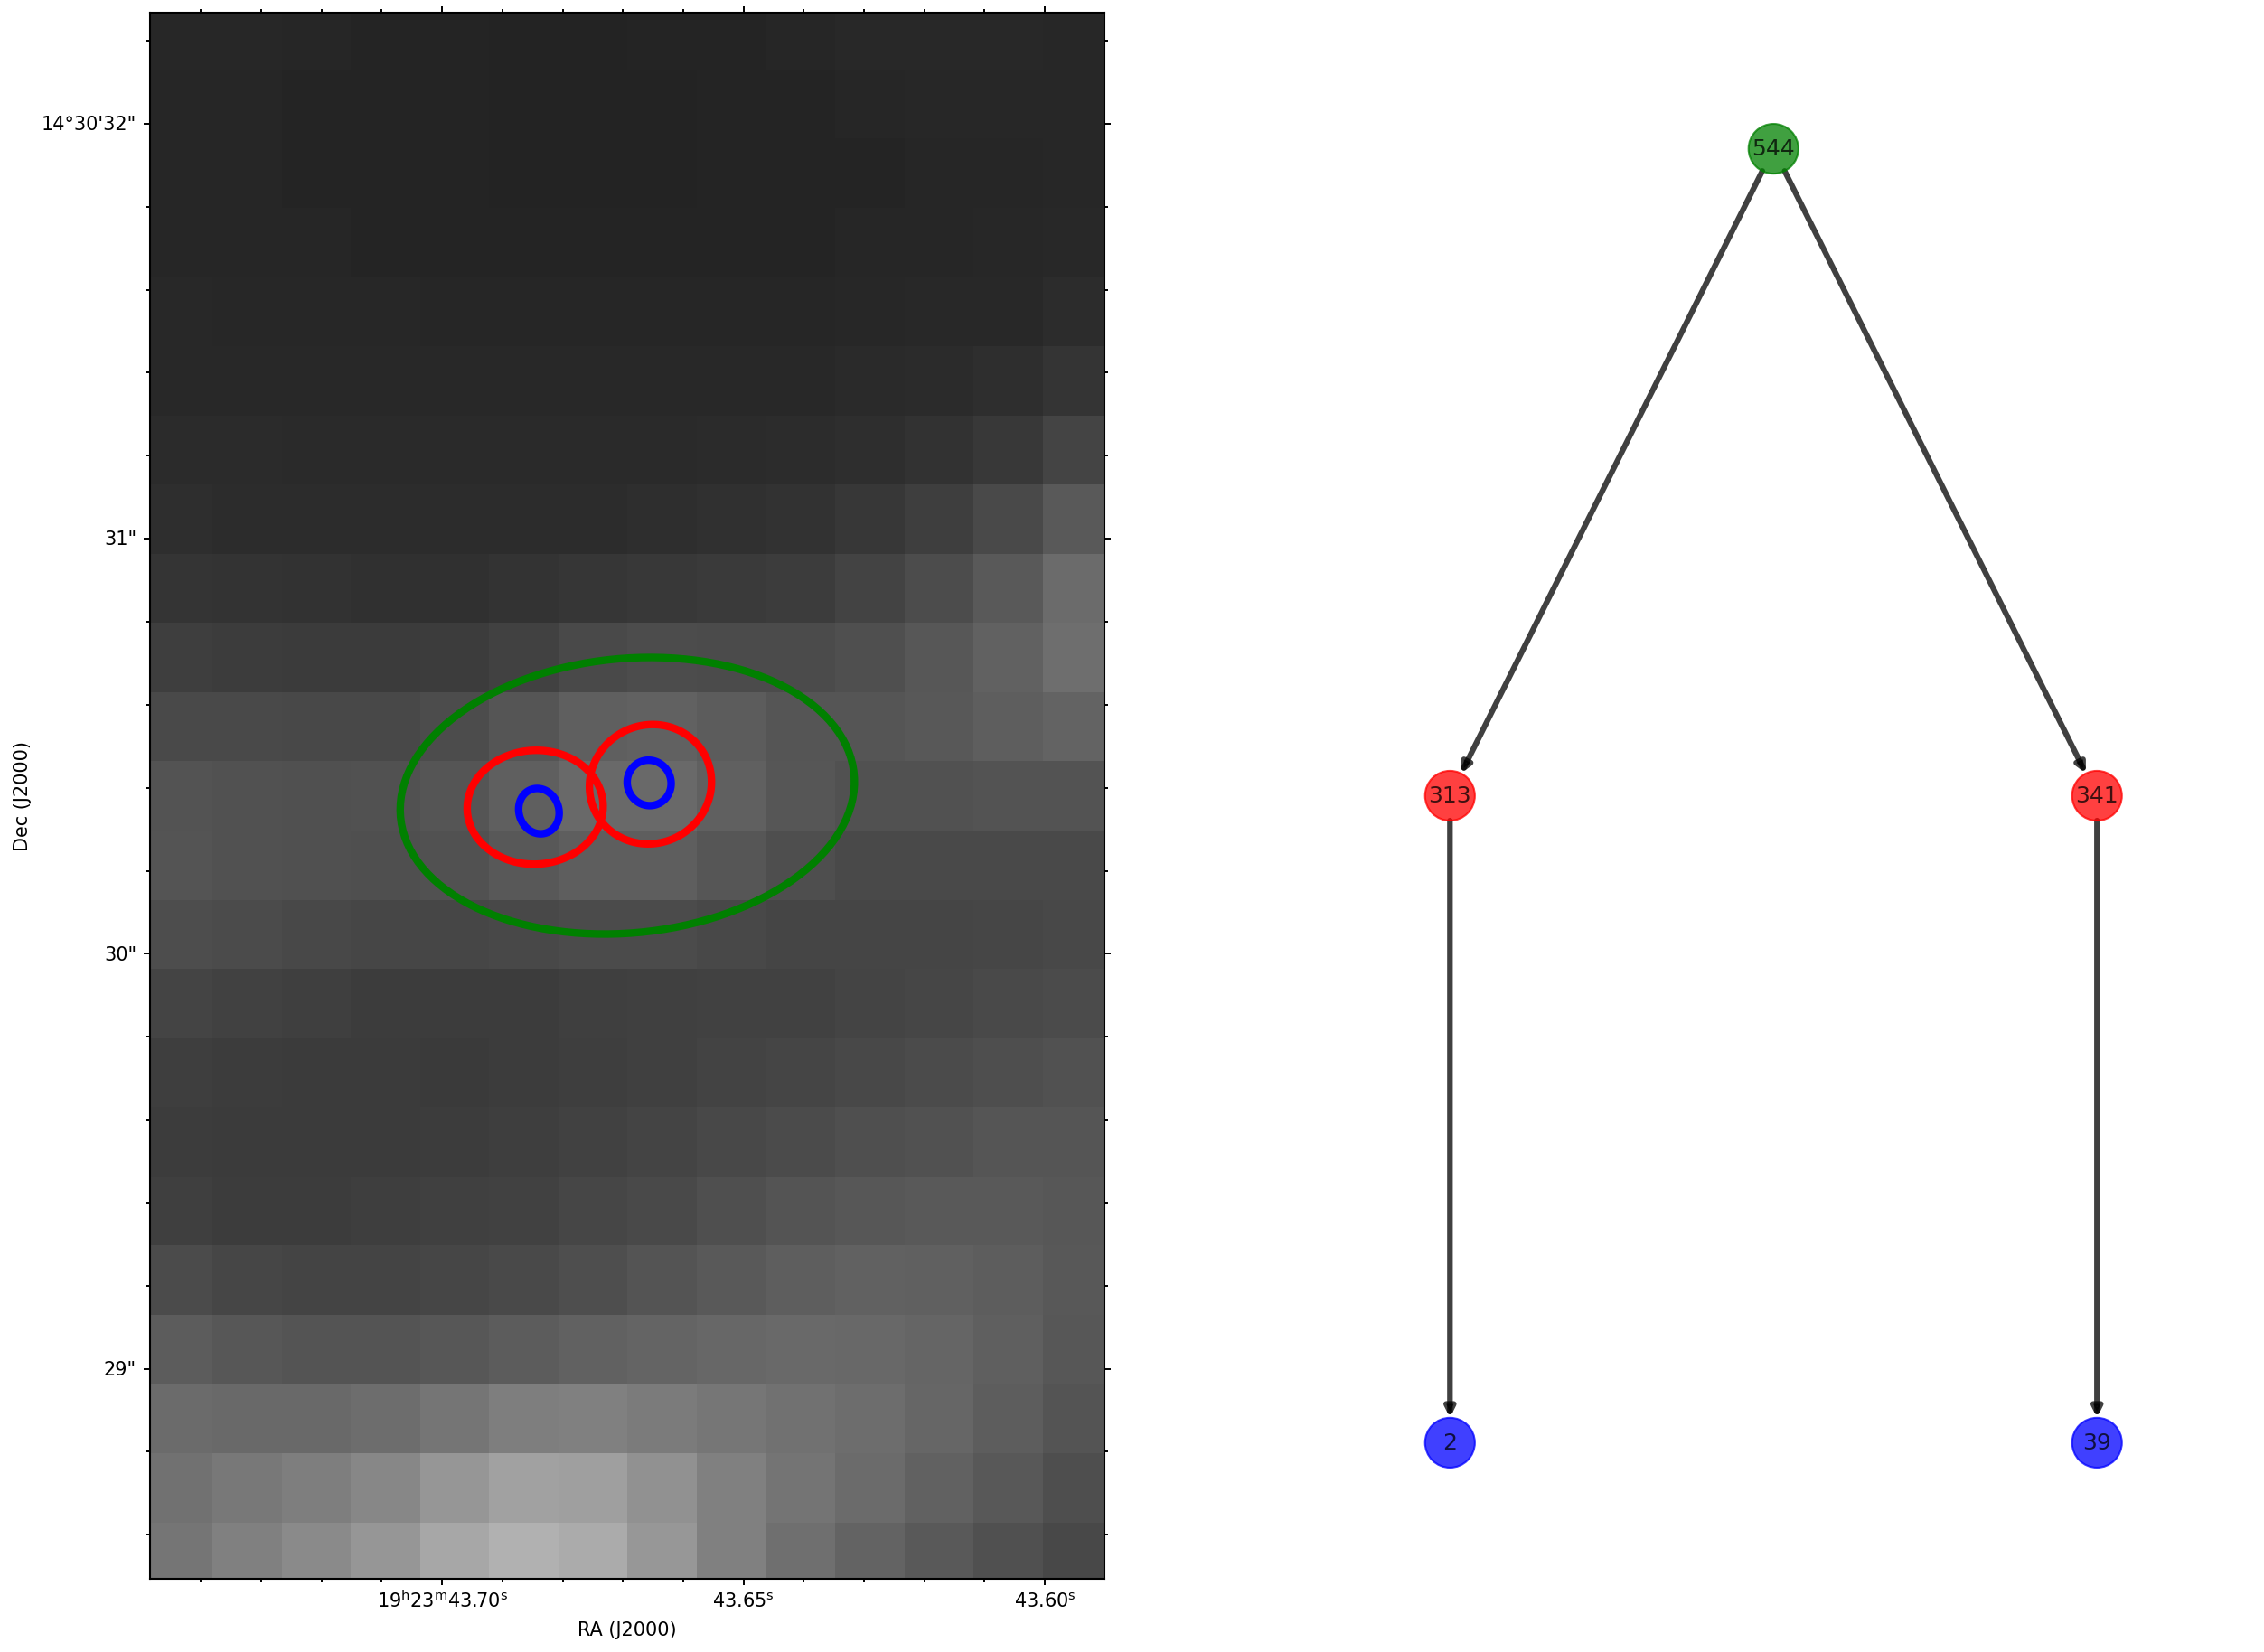

In [8]:
image = dataset._data['2700AU'].fits_img
fig = network.structures[1].plot(image)

In [9]:
plotter.InspectNetwork(network)

INFO: Auto-setting vmin to  9.342e+19 [aplpy.core]
INFO: Auto-setting vmax to  2.230e+24 [aplpy.core]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 2400x2400 with 0 Axes>

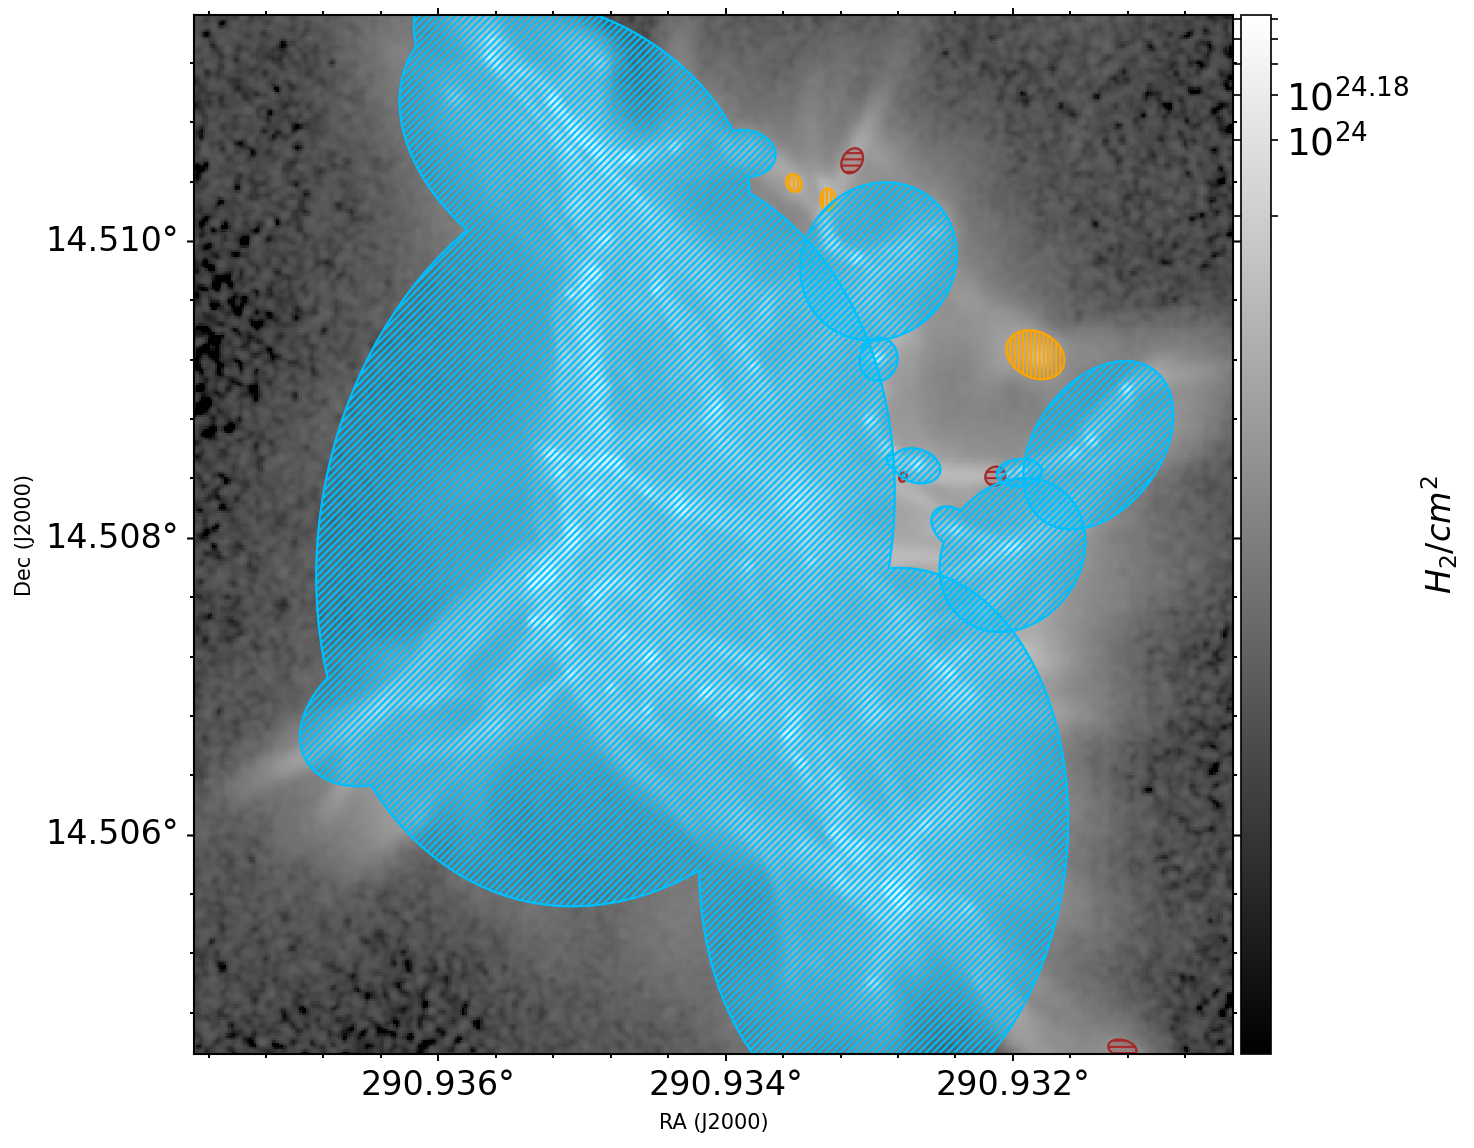

In [18]:
import aplpy
from astropy.io import fits
from astropy.wcs import WCS
from shapely.affinity import rotate

####### Figures Definition
FIGURE = plt.figure(figsize=(16, 16))


colors = ["m", "g", "b", "r", "c"]

hdu = fits.open('benchmark/fits/column_density_01500_z.+.noise.mul1e23.r900au.bor-4650.rs333au.fits')

img = hdu[0].data
hdr = hdu[0].header


vmin = np.nanpercentile(np.where(img>0, img, np.nan), 0.1)
vmax = np.nanpercentile(np.where(img>0, img, np.nan), 99.9)

new_fits = fits.PrimaryHDU(data=img, header=hdr)


fig = aplpy.FITSFigure(new_fits)

#fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 

fig.add_colorbar()
fig.colorbar.set_font(size=12)
fig.colorbar.set_axis_label_font(size=16)

ticks = 10**np.arange(np.log10(vmin), np.log10(vmax))
fig.colorbar.show(log_format=True)
fig.colorbar.set_axis_label_text("$H_2 / cm^2$")
fig.colorbar.set_font(size=18)


fig.tick_labels.set_xformat('dd.ddd')
fig.tick_labels.set_yformat('dd.ddd')
fig.tick_labels.set_font(size=16)


# structures
modes = ['ISOLATED', 'LINEAR', 'HIERARCHICAL']
colors = ['brown',  'orange', 'deepskyblue'] #= azure
hatches = ['----', '||||||', '///////']
alphas = [0.2, 0.2, 0.2]



for mode, color, hatch, alpha in zip(modes, colors, hatches, alphas):
    polygons = structure_table["polygon"][structure_table["mode"] == mode]
    comp = structure_table["component"][structure_table["mode"] == mode]
    PTS = []
    for i, poly in enumerate(polygons):
        node = sorted(comp.values[i].nodes)[-1]
        x, y = poly.exterior.xy
        PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

    fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, alpha=0.5)


#fig.scalebar.show()  # length in degrees
plt.savefig('Struct_Repartition.pdf')

# Fractalité et N vs R

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_75339/1537420724.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Fractalité $\mathcal{F}$")


mean 1.4879800270035013 ; corr =  1.4836315756789267
median 1.444539996293661 ; corr =  1.4705456607041572
carences corr =  1.6045973945693248 +/- 0.1600573982756639
phi2D =  0.6822113598271285 +/- 0.09974925723883743
phi3D =  0.974587656895898 +/- 0.15859373763361756


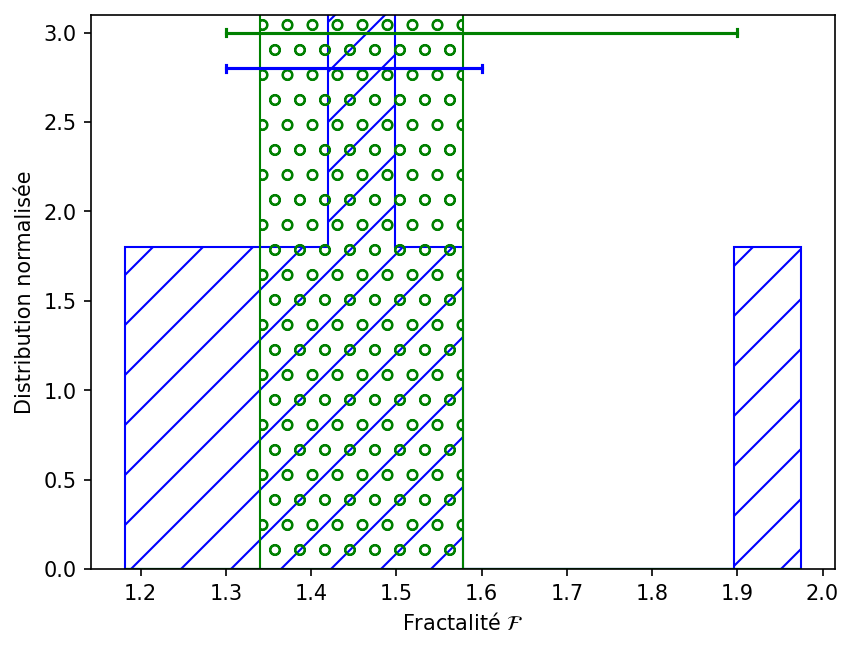

In [ ]:
fractal = []

fractal_160conv = []
fractal_geom = []

fractal_corr = []
missed_corr = []


idx = 0
for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        if idx not in suspicious:
            fractal_corr.append(s.fractality)
            missed_corr.append(s.percmissed)
        fractal.append(s.fractality)
        idx += 1
        
_, bins, _ = plt.hist(fractal, bins=10, density=True, edgecolor="b", histtype='stepfilled',fill=False, hatch='/')
plt.hist(fractal_corr, bins=bins, density=True, edgecolor="g", histtype='stepfilled',fill=False, hatch='o')

dx = 0.15
plt.plot([1.45-0.15, 1.45+0.15], [2.8, 2.8], color="b")
plt.plot([1.45-0.15, 1.45-0.15], [2.78, 2.82], color="b")
plt.plot([1.45+0.15, 1.45+0.15], [2.78, 2.82], color="b")


fract_0 = 1.6
dfract_0 = 0.3
plt.plot([fract_0 - dfract_0, fract_0 + dfract_0], [3, 3], color="g")
plt.plot([fract_0 - dfract_0, fract_0 - dfract_0], [2.98, 3.02], color="g")
plt.plot([fract_0 + dfract_0, fract_0 + dfract_0], [2.98, 3.02], color="g")

plt.xlabel("Fractalité $\mathcal{F}$")
plt.ylabel("Distribution normalisée")

plt.ylim([0, 3.1])

print("mean", np.mean(fractal), "; corr = ", np.mean(fractal_corr))
print("median", np.median(fractal), "; corr = ", np.median(fractal_corr))
#print("maxmissed", np.max(missed_corr))

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print("carences corr = ", fractality_corr_carences, "+/-", dfractality_corr_carences)

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print("phi2D = ", phi2D, "+/-", dphi2D)


f = -0.3
df = 0.05

d1 = (dphi2D/(1 + f))**2
d2 = (phi2D / (1 + f)**2 * df) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print("phi3D = ", phi3D, "+/-", dphi3D)

mean prod. y axis = [np.float64(12.678571428571429), np.float64(9.214285714285714), np.float64(2.357142857142857), np.float64(1.6666666666666665), np.float64(1.0)]


Text(0, 0.5, '$<N_{tot}/N_{tot}^0>$')

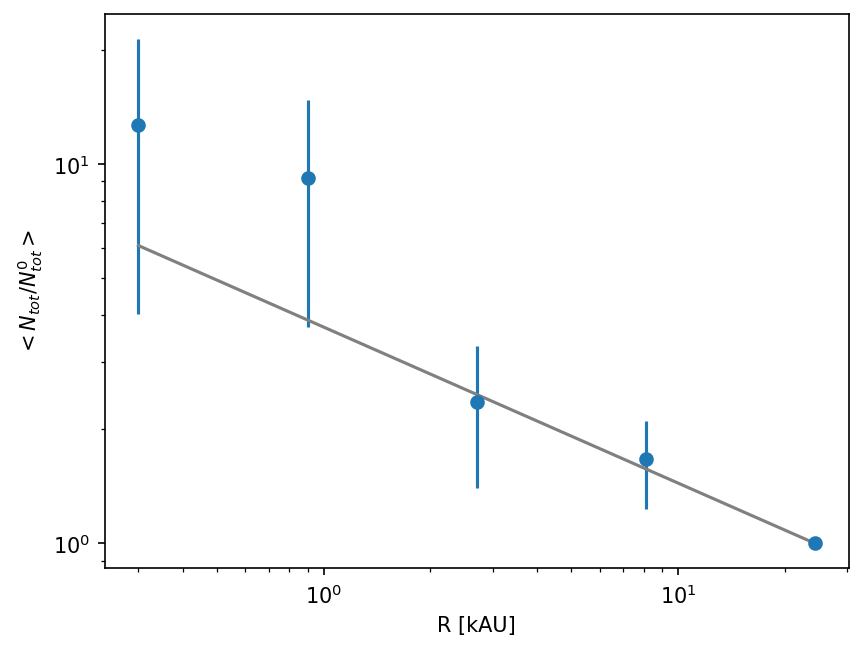

In [ ]:
distance = network.data[-1].distance
x, meany, stdy = plotter.getFragCurve(network, distance, mode = "HIERARCHICAL")

print("mean prod. y axis =", meany)

fig, ax = plt.subplots()

x_kau = x / 1000
ax.errorbar(x_kau, meany, stdy, np.zeros_like(x), "o")

fractality = np.mean(1.33)
fractality_arr = np.ones_like(x) * fractality
exponent = -(np.log(fractality_arr)/np.log(2))

ax.plot(x_kau, (x / max(x))**exponent, "-", color="grey")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("R [kAU]")
ax.set_ylabel("$<N_{tot}/N_{tot}^0>$")

# Uncertainties with virtual nodes

In [ ]:
nb_node = []

fractal = []
suspicious = []
fractal_160conv = []
fractal_geom = []

fractal_corr = []
missed_corr = []

n_core_lin = 0
n_core_iso = 0
n_core_hier = 0
idx = 0
number_h = 0
number_l = 0
number_i = 0
number_iso43 = 0
for s in network.structures:
    #print(s.component.in_degree)
    if s.mode.name == "HIERARCHICAL":# or s.mode.name == "LINEAR":
        if idx not in suspicious:
            fractal_corr.append(s.fractality)
            missed_corr.append(s.percmissed)
            number_h += 1
            n_core_hier += len(s.component)
        fractal.append(s.fractality)
        idx += 1
        nb_node.append(len(s.component))
    if s.mode.name == "LINEAR":
        number_l += 1
        n_core_lin += len(s.component)
    if s.mode.name == "ISOLATED":
        number_iso43 += 1
        number_i += 1
        n_core_iso += len(s.component)

print("number of hierarchical cores = ", n_core_hier)
print("number of linear cores = ", n_core_lin)
print("number of isolated cores = ", n_core_iso)
print("number of hierarchical structures = ", number_h)
print("number of isolated structures with scale 0.43 = ", number_iso43)
print("number of linear structures = ", number_l)
print("number of isolated structures = ", number_i) 
print("------------------------------------------------\n")

#print(fractal)
print("mean", np.mean(fractal), "+/-", np.std(fractal))
print("median", np.median(fractal), 'corr = ', np.median(fractal_corr))

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print("carences corr = ", fractality_corr_carences)

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print("phi2D = ", phi2D, "+/-", dphi2D)


projection_error = -0.3
dprojection_error = 0.05

d1 = (dphi2D/(1 + projection_error))**2
d2 = (phi2D / (1 + projection_error)**2 * dprojection_error) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print("phi3D = ", phi3D, "+/-", dphi3D)
print("F_3D =", np.exp(phi3D*np.log(2)))
print("Number of node in the Hierarchical come from",np.min(nb_node)," to ",np.max(nb_node))

number of hierarchical cores =  560
number of linear cores =  6
number of isolated cores =  4
number of hierarchical structures =  7
number of isolated structures with scale 0.43 =  4
number of linear structures =  3
number of isolated structures =  4
------------------------------------------------

mean 1.4879800270035013 +/- 0.23070024397143027
median 1.444539996293661 corr =  1.444539996293661
carences corr =  1.588993995923027
phi2D =  0.6681136734161747 +/- 0.09090909090909093
phi3D =  0.9544481048802496 +/- 0.1466767288985885
F_3D = 1.937838182631886
Number of node in the Hierarchical come from 4  to  501


In [ ]:
virtual = utility.virtualNodes(network.network, network.levels)

In [ ]:
network_virtualfill = analyse.Network(analyse.DataSet(network.data), min_overlap=network.min_overlap, graph=virtual)

utility.fractality(network_virtualfill.network)

clumps = utility.toDataFrame(network_virtualfill.network)

network_virtualfill.extractStructures()
structure_table_virtual = network_virtualfill.getStructuresTable()

median with virtual nodes 1.548562654849427
median without virtual nodes 1.444539996293661


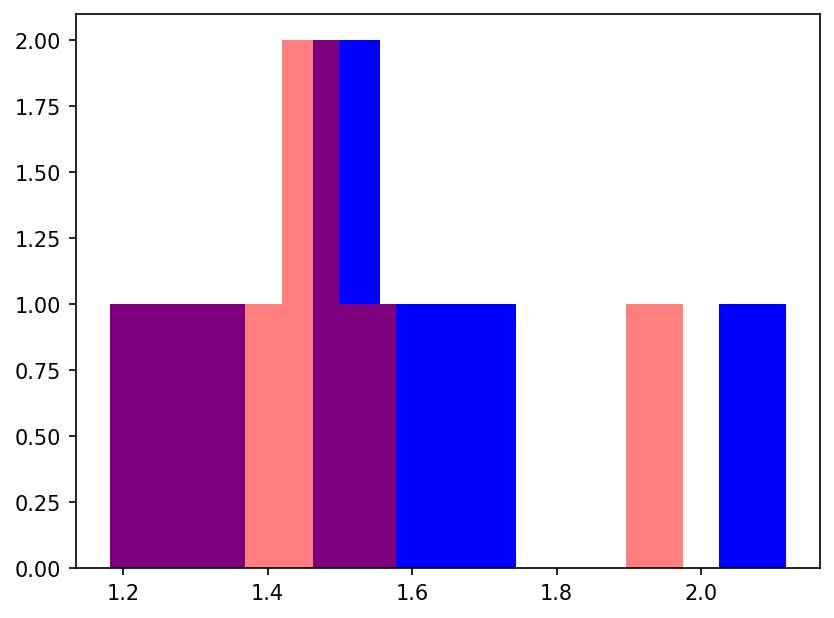

In [ ]:
plt.hist(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"], color="b")
plt.hist(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"], color="r", alpha=0.5)

print("median with virtual nodes", np.median(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"]))
print("median without virtual nodes", np.median(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"]))

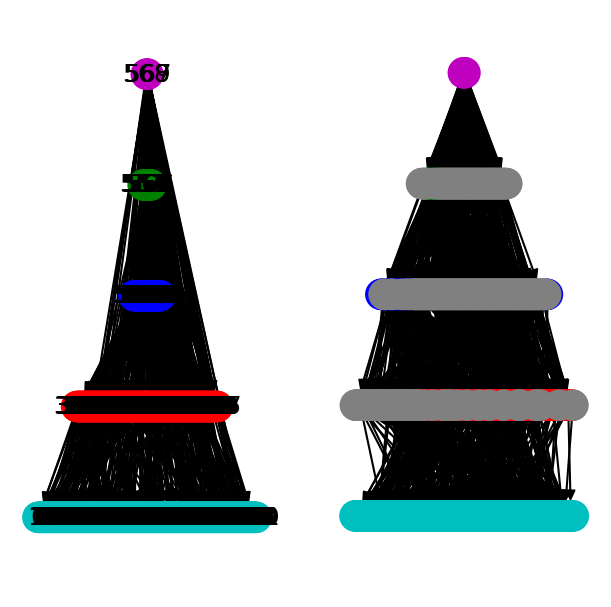

In [ ]:
import networkx as nx
# Check virtuals

hierarchical_structures = structure_table["component"][structure_table["mode"] == "HIERARCHICAL"]
hierarchical_structures_virtuals = structure_table_virtual["component"][structure_table_virtual["mode"] == "HIERARCHICAL"]

idx = 0
struct = hierarchical_structures.array[idx]
struct_virtual = hierarchical_structures_virtuals.array[idx]

colors = ["m", "g", "b", "r", "c"][::-1]
scales = network.levels
colors = {str(scale):color for color, scale in zip(colors, scales)}

color = []
for _, b in struct.nodes("_beam"):
    if b != 2.:
        color.append(colors[str(b)])
    else:
        color.append("grey")

color_virtual = []
for node, b in struct_virtual.nodes("_beam"):
    if b != 2. and struct_virtual.nodes[node]["_Kind"].name != "VIRTUAL":
        color_virtual.append(colors[str(b)])
    elif b ==2:
        color_virtual.append("k")
    else:
        color_virtual.append("grey")
                
figure, axs = plt.subplots(ncols=2, figsize=(5, 5))

# without virtuals
pos = nx.multipartite_layout(struct, subset_key="_level", align="horizontal")
nx.draw(struct, pos, ax=axs[0], node_color=color, node_size=200, with_labels=True)

# with virtuals
pos = nx.multipartite_layout(struct_virtual, subset_key="_level", align="horizontal")
nx.draw(struct_virtual, pos, ax=axs[1], node_color=color_virtual, node_size=200, with_labels=False)

In [ ]:
def fragmentation_rate2D(fractality, uncertainty):
    return np.log(fractality)/np.log(2), uncertainty/fractality/np.log(2)

for structure_real, structure_hole in zip(network.structures, network_virtualfill.structures):

    fractality = (structure_real.fractality + structure_hole.fractality)/2
    uncertainty = abs(structure_real.fractality - structure_hole.fractality)/2
    
    phi, dphi = fragmentation_rate2D(fractality, uncertainty)

    structure_real.fragmentation_rate = phi, dphi
    

In [ ]:
for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        print(s.fragmentation_rate)

(np.float64(1.0330163440483806), np.float64(0.05025795527938258))
(np.float64(0.40567607429452696), np.float64(0.0))
(np.float64(0.2407556313299972), np.float64(0.0))
(np.float64(0.5816417582063887), np.float64(0.0501396013201136))
(np.float64(0.5381903551961341), np.float64(0.034968376384484676))
(np.float64(0.6908002177214809), np.float64(0.03369128897780236))
(np.float64(0.641131280463289), np.float64(0.05827968383166814))
